In [1]:
%load_ext autoreload
%autoreload 2

In [48]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from src.possession_parser import Possession_parser
from src.score_event_parser import Score_parser

In [3]:
con = duckdb.connect(database='data/nba.sqlite', read_only=False)

In [60]:
teams = con.query('select * from team').fetchdf()
teams

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949.0
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946.0
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970.0
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002.0
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966.0
5,1610612742,Dallas Mavericks,DAL,Mavericks,Dallas,Texas,1980.0
6,1610612743,Denver Nuggets,DEN,Nuggets,Denver,Colorado,1976.0
7,1610612744,Golden State Warriors,GSW,Warriors,Golden State,California,1946.0
8,1610612745,Houston Rockets,HOU,Rockets,Houston,Texas,1967.0
9,1610612746,Los Angeles Clippers,LAC,Clippers,Los Angeles,California,1970.0


In [31]:
game_info_df = con.query("select * from game").fetchdf()
game_info_df

,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type
0,21946,1610610035,HUS,Toronto Huskies,0024600001,1946-11-01,HUS vs. NYK,L,0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,21946,1610610034,BOM,St. Louis Bombers,0024600003,1946-11-02,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,21946,1610610032,PRO,Providence Steamrollers,0024600002,1946-11-02,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season
3,21946,1610610025,CHS,Chicago Stags,0024600004,1946-11-02,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,22.0,47.0,-16,0,Regular Season
4,21946,1610610028,DEF,Detroit Falcons,0024600005,1946-11-02,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,50.0,17,0,Regular Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65693,42022,1610612748,MIA,Miami Heat,0042200403,2023-06-07,MIA vs. DEN,L,240,34.0,...,58.0,28.0,3.0,5.0,14.0,18.0,109.0,15,1,Playoffs
65694,42022,1610612748,MIA,Miami Heat,0042200404,2023-06-09,MIA vs. DEN,L,240,35.0,...,34.0,26.0,11.0,7.0,8.0,18.0,108.0,13,1,Playoffs
65695,42022,1610612743,DEN,Denver Nuggets,0042200405,2023-06-12,DEN vs. MIA,W,240,38.0,...,44.0,18.0,9.0,7.0,8.0,21.0,89.0,-5,1,Playoffs
65696,32022,1610616834,LBN,Team LeBron,0032200001,2023-02-19,LBN vs. GNS,L,221,79.0,...,46.0,43.0,8.0,1.0,12.0,2.0,184.0,9,1,All-Star


In [35]:
print(game_info_df['season_type'].unique())

['Regular Season' 'Playoffs' 'All-Star' 'All Star' 'Pre Season']


In [33]:
print(game_info_df.columns)

Index(['season_id', 'team_id_home', 'team_abbreviation_home', 'team_name_home',
       'game_id', 'game_date', 'matchup_home', 'wl_home', 'min', 'fgm_home',
       'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home',
       'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home',
       'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home',
       'pts_home', 'plus_minus_home', 'video_available_home', 'team_id_away',
       'team_abbreviation_away', 'team_name_away', 'matchup_away', 'wl_away',
       'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away',
       'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away',
       'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away',
       'pf_away', 'pts_away', 'plus_minus_away', 'video_available_away',
       'season_type'],
      dtype='object')


In [124]:
team_ids = teams['id']
regular_games = (game_info_df['season_type'] == 'Regular Season') | (game_info_df['season_type'] == 'Playoffs')
game_info_df = game_info_df[regular_games]

In [125]:
team_game_outcomes = pd.DataFrame(columns=['team_id', 'game_id', 'is_home', 'plus_minus'])
for team_id in team_ids:
    print(f'processing {team_id}')
    home_games = game_info_df[game_info_df['team_id_home'] == team_id]
    for index, game in home_games.iterrows():
        cur_game = {
            'team_id': [team_id],
            'game_id': [game['game_id']],
            'is_home': [True],
            'plus_minus': [game['plus_minus_home']]}
        new_row_df = pd.DataFrame(cur_game)
        team_game_outcomes = pd.concat([team_game_outcomes, new_row_df], ignore_index=True)

    away_games = game_info_df[game_info_df['team_id_away'] == team_id]
    for index, game in away_games.iterrows():
        cur_game = {
            'team_id': [team_id],
            'game_id': [game['game_id']],
            'is_home': [False],
            'plus_minus': [game['plus_minus_away']]}
        new_row_df = pd.DataFrame(cur_game)
        team_game_outcomes = pd.concat([team_game_outcomes, new_row_df], ignore_index=True)

processing 1610612737
processing 1610612738
processing 1610612739
processing 1610612740
processing 1610612741
processing 1610612742
processing 1610612743
processing 1610612744
processing 1610612745
processing 1610612746
processing 1610612747
processing 1610612748
processing 1610612749
processing 1610612750
processing 1610612751
processing 1610612752
processing 1610612753
processing 1610612754
processing 1610612755
processing 1610612756
processing 1610612757
processing 1610612758
processing 1610612759
processing 1610612760
processing 1610612761
processing 1610612762
processing 1610612763
processing 1610612764
processing 1610612765
processing 1610612766


In [126]:
team_game_outcomes.to_csv('data/game_outcomes_per_team.csv', index=None)

In [ ]:
team_idx = 10
team_id = team_ids[team_idx]
print(team_id)
team_name = teams.loc[teams['id'] == team_id]['full_name'][team_idx]
print(team_name)

1610612747
Los Angeles Lakers


6136


Text(0.5, 1.0, 'Los Angeles Lakers (away)')

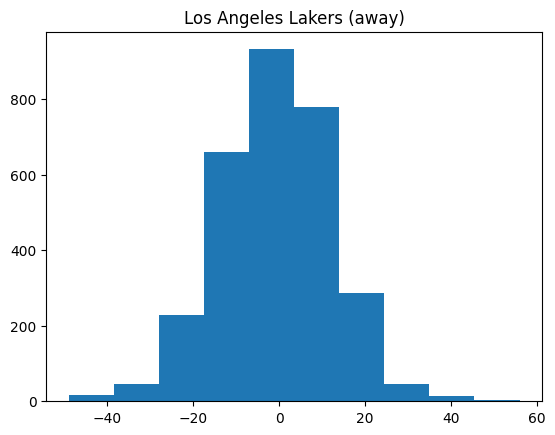

In [121]:
print(team_game_outcomes[team_game_outcomes['team_id'] == team_id].shape[0])
team_pm = team_game_outcomes[(team_game_outcomes['team_id'] == team_id) & (team_game_outcomes['is_home'] == False)]['plus_minus']
fig, ax = plt.subplots()
ax.hist(team_pm)
ax.set_title(f'{team_name} (away)')

In [4]:
game_ids_df = con.query("select distinct game_id from play_by_play").fetchdf()
game_ids = game_ids_df['game_id']

In [5]:
cur_game_id = game_ids[0]
game_df = con.query(f"select * from play_by_play where game_id = '{cur_game_id}'").fetchdf()
game_df = game_df.sort_values(by='eventnum')

In [6]:
print(game_df.columns)

Index(['game_id', 'eventnum', 'eventmsgtype', 'eventmsgactiontype', 'period',
       'wctimestring', 'pctimestring', 'homedescription', 'neutraldescription',
       'visitordescription', 'score', 'scoremargin', 'person1type',
       'player1_id', 'player1_name', 'player1_team_id', 'player1_team_city',
       'player1_team_nickname', 'player1_team_abbreviation', 'person2type',
       'player2_id', 'player2_name', 'player2_team_id', 'player2_team_city',
       'player2_team_nickname', 'player2_team_abbreviation', 'person3type',
       'player3_id', 'player3_name', 'player3_team_id', 'player3_team_city',
       'player3_team_nickname', 'player3_team_abbreviation',
       'video_available_flag'],
      dtype='object')


In [29]:
print(game_df.iloc[game_df.shape[0]-1])

game_id                                           0029600614
eventnum                                                 474
eventmsgtype                                              13
eventmsgactiontype                                         0
period                                                     4
wctimestring                                         1:12 AM
pctimestring                                            0:00
homedescription                                         None
neutraldescription           End of 4th Period (1:12 AM EST)
visitordescription                                      None
score                                               99 - 114
scoremargin                                               15
person1type                                              0.0
player1_id                                                 0
player1_name                                            None
player1_team_id                                         None
player1_team_city       

In [ ]:
score_parser = Score_parser(game_df)
scores = score_parser.parse_game()
scores

In [12]:
parser = Possession_parser(game_df)
possessions = parser.parse_game()
possessions

free throw
free throw
timeout
timeout
free throw
free throw
free throw
free throw
free throw
free throw
player not on offense scored at row 95 , handling it
    eventmsgtype  eventmsgactiontype                 homedescription  \
85             4                   0                            None   
86             6                   2         Ostertag S.FOUL (P2.T4)   
87             8                   0          SUB: Carr FOR Ostertag   
88             3                  11                            None   
89             3                  12                            None   
90             6                   2                            None   
91             3                  11  Carr Free Throw 1 of 2 (1 PTS)   
92             8                   0                            None   
93             8                   0                            None   
94             3                  12  Carr Free Throw 2 of 2 (2 PTS)   
95             1                   1               

,game_id,possession_id,offense_team_id,possession_end_event_type,possession_end_points,active_team0_ids,active_team1_ids
0,0029600296,0,1610612756.0,4.0,0,"['731', '935', '252', '204', '458']","['73', '920', '445', '714', '134']"
1,0029600296,1,1610612762.0,4.0,0,"['731', '935', '252', '204', '458']","['73', '920', '445', '714', '134']"
2,0029600296,2,1610612756.0,3.11,0,"['731', '935', '252', '204', '458']","['73', '920', '445', '714', '134']"
3,0029600296,3,1610612762.0,5.1,0,"['731', '935', '252', '204', '458']","['73', '920', '445', '714', '134']"
4,0029600296,4,1610612756.0,1.1,2,"['731', '935', '252', '204', '458']","['73', '920', '445', '714', '134']"
...,...,...,...,...,...,...,...
509,0029600296,200,1610612756.0,3.11,0,"['304', '252', '935', '204', '156']","['330', '364', '109', '714', '73']"
510,0029600296,201,1610612762.0,6.1,0,"['304', '252', '935', '204', '156']","['330', '364', '109', '134', '714']"
511,0029600296,202,1610612756.0,3.11,0,"['304', '252', '935', '204', '156']","['330', '364', '109', '134', '714']"
512,0029600296,203,1610612762.0,4.0,0,"['304', '252', '935', '204', '156']","['330', '364', '109', '134', '714']"


In [19]:
print(game_df.loc[(game_df['eventmsgtype'] == 1) | (game_df['eventmsgtype'] == 3)][['pctimestring', 'homedescription', 'visitordescription']])

    pctimestring                                 homedescription  \
4          11:33                    Foster 10' Jump Shot (2 PTS)   
11         10:55                   MISS Malone Free Throw 1 of 2   
13         10:55                Malone Free Throw 2 of 2 (1 PTS)   
19         10:00   Malone 20' Jump Shot (3 PTS) (Hornacek 1 AST)   
20          9:37                                            None   
..           ...                                             ...   
454         0:55                                            None   
455         0:55                                            None   
456         0:36  Malone 19' Jump Shot (25 PTS) (Stockton 9 AST)   
462         0:02                        Malone Tip Shot (27 PTS)   
465         0:02               Malone Free Throw 1 of 1 (28 PTS)   

                               visitordescription  
4                                            None  
11                                           None  
13                         

In [10]:
print(game_df.loc[(game_df['eventmsgtype'] == 3)][['eventnum', 'pctimestring', 'homedescription', 'visitordescription', 'player1_id']])

     eventnum pctimestring                      homedescription  \
11         12        10:55        MISS Malone Free Throw 1 of 2   
13         14        10:55     Malone Free Throw 2 of 2 (1 PTS)   
27         29         8:50                                 None   
29         31         8:50                                 None   
33         35         8:25                                 None   
..        ...          ...                                  ...   
451       456         1:08  Stockton Free Throw 1 of 2 (17 PTS)   
452       457         1:08  Stockton Free Throw 2 of 2 (18 PTS)   
454       459         0:55                                 None   
455       460         0:55                                 None   
465       471         0:02    Malone Free Throw 1 of 1 (28 PTS)   

                    visitordescription player1_id  
11                                None        252  
13                                None        252  
27      MISS Johnson Free Throw 1 of 2 

In [112]:
game_df[["homedescription",	"neutraldescription"	,"visitordescription"]]

,homedescription,neutraldescription,visitordescription
0,Jump Ball Geiger vs. Baker: Tip to Robinson,None,None
1,None,None,MISS Baker Layup
2,None,None,Bucks Rebound
3,None,None,MISS Allen Layup
4,Mason REBOUND (Off:0 Def:1),None,None
...,...,...,...
441,Geiger STEAL (1 STL),None,Robinson Bad Pass Turnover (P4.T12)
442,MISS Rice 3PT Jump Shot,None,None
443,Mason REBOUND (Off:3 Def:9),None,None
444,HORNETS Timeout: Regular (Full 7 Short 2),None,None
